# Cytokine Signaling Dynamics — Bootstrap Experiment

Randomly samples **5 simple** and **5 complex** cytokines from pre-defined hypothesis
pools, then runs the full AB-MIL pipeline on those 10 + PBS = 11 classes.

## Hypothesis (pre-registered)

> **Simple cytokines** (direct, PBMC-expressed receptor, strong 24-h transcriptional
> response) should rank **higher** in learnability AUC than **complex cytokines**
> (indirect, cascade-dependent, or non-PBMC-primary targets).

**Simple pool:** cytokines with a well-characterized receptor expressed on PBMCs that
induces a strong, detectable transcriptional program within 24 hours.

**Complex pool:** cytokines that target non-PBMC cell types primarily, signal through
secondary mediators, or induce subtle, pleiotropic, or context-dependent programs.

**Expected direction:** mean learnability AUC(simple) > mean learnability AUC(complex).
Tested post-training with a one-sided Mann-Whitney U test (never repeated to avoid p-hacking).

---

Connect to the cluster kernel before running.  
All paths in `configs/default.yaml` point to cluster storage.

In [1]:
import json
import random
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, mannwhitneyu
from torch.utils.data import DataLoader

from cytokine_mil.data.label_encoder import CytokineLabel
from cytokine_mil.data.dataset import PseudoTubeDataset, CellDataset
from cytokine_mil.models.instance_encoder import InstanceEncoder
from cytokine_mil.models.attention import AttentionModule
from cytokine_mil.models.bag_classifier import BagClassifier
from cytokine_mil.models.cytokine_abmil import CytokineABMIL
from cytokine_mil.training.train_encoder import train_encoder
from cytokine_mil.training.train_mil import train_mil
from cytokine_mil.experiment_setup import (
    build_stage1_manifest,
    filter_manifest,
    split_manifest_by_donor,
    build_encoder,
    build_mil_model,
)
from cytokine_mil.analysis.dynamics import (
    aggregate_to_donor_level,
    rank_cytokines_by_learnability,
    compute_cytokine_entropy_summary,
    compute_confusion_entropy_summary,
    build_cell_type_confidence_matrix,
)
from cytokine_mil.analysis.validation import (
    check_seed_stability,
    check_functional_groupings,
)

In [2]:
# ============================================================
# TOP-LEVEL CONTROLS — change these to reproduce or vary the experiment
# ============================================================

BOOTSTRAP_SEED     = 42   # Controls which 5+5 cytokines are sampled from the pools.
                          # Change this to run a different draw. Document the seed
                          # in your results to make the experiment reproducible.

N_SAMPLE_PER_GROUP = 5   # Number of cytokines sampled from each pool.

# ============================================================

with open("cytokines/cytokines-mil/configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAINING_SEED = cfg["dynamics"]["random_seeds"][0]   # separate from bootstrap seed

print(f"Device:          {DEVICE}")
print(f"Bootstrap seed:  {BOOTSTRAP_SEED}  (controls cytokine sampling)")
print(f"Training seed:   {TRAINING_SEED}   (controls model initialization)")

Device:          cuda
Bootstrap seed:  42  (controls cytokine sampling)
Training seed:   42   (controls model initialization)


## 1. Data

In [3]:
MANIFEST_PATH = cfg["data"]["manifest_path"]

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

HVG_PATH = str(Path(MANIFEST_PATH).parent / "hvg_list.json")
with open(HVG_PATH) as f:
    gene_names = json.load(f)

print(f"Full manifest entries: {len(manifest)}")
print(f"HVGs: {len(gene_names)}")

Full manifest entries: 10920
HVGs: 4000


In [4]:
# --- Bootstrap cytokine pools ---
# Names must exactly match the cytokine field in manifest.json.
#
# Name corrections vs user-facing notation (from pseudo_tubes_creation.ipynb output):
#   IL-1β  → IL-1-beta
#   IFN-β  → IFN-beta
#   IL-32β → IL-32-beta
#   TGF-β  → TGF-beta1   (manifest has the "1" suffix)

SIMPLE_POOL = [
    "IL-4",       # strong Th2/B cell axis via STAT6 — ranked #1 in full-experiment preliminary run
    "IL-10",      # strong monocyte/B cell response via STAT3 — ranked #4 in preliminary run
    "IL-2",       # direct T/NK activation via γc receptor — ranked #10 in preliminary run
    "M-CSF",      # direct monocyte survival/activation via CSF1R — ranked #3 in preliminary run
    "TNF-alpha",  # canonical early NF-κB in monocytes/T cells — rapid direct inflammatory activator
    "IL-1-beta",  # canonical NF-κB/IL-1R1 activator on monocytes/T cells — fast acute response
    "IFN-beta",   # type I IFN via IFNAR1/2 — direct antiviral ISG program in all PBMC types
    "IL-7",       # direct lymphocyte survival via γc/IL-7Rα — clear T/NK cell receptor expression
    "G-CSF",      # direct myeloid differentiation via G-CSFR (CSF3R) on granulocyte precursors
]

COMPLEX_POOL = [
    "IL-12",      # cascade control: drives IFN-γ in NK/T cells indirectly (Fig. 4i in source paper)
    "IL-32-beta", # signals through TNF-α/IL-18 induction — indirect, unclear PBMC receptor
    "OSM",        # Oncostatin M — non-PBMC primary targets; near bottom in preliminary run
    "IL-22",      # targets epithelium via IL-22R1 — minimal direct PBMC transcriptional signal
    "VEGF",       # endothelial target via VEGFR — PBMCs lack significant VEGFR expression
    "HGF",        # hepatocyte/stromal target via c-Met — weak direct PBMC response
    "TGF-beta1",  # broad immunosuppressive cytokine with complex, context-dependent PBMC effects
    "IL-6",       # pleiotropic gp130 signaling — trans-signaling confounds PBMC readout
]

# Verify all pool names exist in manifest before sampling
manifest_cytokines = {e["cytokine"] for e in manifest}
missing_simple  = [c for c in SIMPLE_POOL  if c not in manifest_cytokines]
missing_complex = [c for c in COMPLEX_POOL if c not in manifest_cytokines]

if missing_simple or missing_complex:
    print("WARNING — some pool cytokines not found in manifest (check naming):")
    if missing_simple:  print(f"  Simple pool:  {missing_simple}")
    if missing_complex: print(f"  Complex pool: {missing_complex}")
    print(f"Available names (sample): {sorted(manifest_cytokines)[:30]}")
else:
    print(f"All pool cytokines found in manifest.")
    print(f"Simple pool  ({len(SIMPLE_POOL)}): {SIMPLE_POOL}")
    print(f"Complex pool ({len(COMPLEX_POOL)}): {COMPLEX_POOL}")

All pool cytokines found in manifest.
Simple pool  (9): ['IL-4', 'IL-10', 'IL-2', 'M-CSF', 'TNF-alpha', 'IL-1-beta', 'IFN-beta', 'IL-7', 'G-CSF']
Complex pool (8): ['IL-12', 'IL-32-beta', 'OSM', 'IL-22', 'VEGF', 'HGF', 'TGF-beta1', 'IL-6']


In [5]:
# --- Seeded random sampling ---
# BOOTSTRAP_SEED is defined in the top-level controls cell above.
# Changing it selects a different draw; all downstream results use the sampled subset.

_rng = random.Random(BOOTSTRAP_SEED)
SIMPLE_CYTOKINES  = sorted(_rng.sample(SIMPLE_POOL,  N_SAMPLE_PER_GROUP))
COMPLEX_CYTOKINES = sorted(_rng.sample(COMPLEX_POOL, N_SAMPLE_PER_GROUP))
SUBSET_CYTOKINES  = SIMPLE_CYTOKINES + COMPLEX_CYTOKINES

print(f"Bootstrap seed:  {BOOTSTRAP_SEED}")
print(f"Sampled simple  ({len(SIMPLE_CYTOKINES)}): {SIMPLE_CYTOKINES}")
print(f"Sampled complex ({len(COMPLEX_CYTOKINES)}): {COMPLEX_CYTOKINES}")
print(f"Full subset     ({len(SUBSET_CYTOKINES)})  : {SUBSET_CYTOKINES}")

Bootstrap seed:  42
Sampled simple  (5): ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4']
Sampled complex (5): ['HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']
Full subset     (10)  : ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4', 'HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']


In [6]:
# Filter manifest to the 10-cytokine subset + PBS
subset_manifest = filter_manifest(manifest, cytokines=SUBSET_CYTOKINES, include_pbs=True)

subset_cytokine_names = {e["cytokine"] for e in subset_manifest}
print(f"Subset manifest entries: {len(subset_manifest)}")
print(f"Unique classes: {sorted(subset_cytokine_names)}")
print(f"n_classes = {len(subset_cytokine_names)}  (10 cytokines + PBS)")

Subset manifest entries: 1320
Unique classes: ['G-CSF', 'HGF', 'IL-1-beta', 'IL-10', 'IL-12', 'IL-2', 'IL-22', 'IL-32-beta', 'IL-4', 'PBS', 'VEGF']
n_classes = 11  (10 cytokines + PBS)


In [7]:
# Label encoder — fitted on subset manifest for consistent index mapping
LABEL_ENCODER_PATH = str(
    Path(MANIFEST_PATH).parent / f"label_encoder_bootstrap_{BOOTSTRAP_SEED}.json"
)
label_encoder = CytokineLabel().fit(subset_manifest)
label_encoder.save(LABEL_ENCODER_PATH)
print(f"Classes: {label_encoder.n_classes()} (PBS at index {label_encoder.encode('PBS')})")

Classes: 91 (PBS at index 90)


In [8]:
# --- Donor-level train/val split (see CLAUDE.md Section 16) ---
# D2 and D3 are the most biologically distinct donors in the cohort.
# They are held out for generalization testing and never used in optimizer steps.
VAL_DONORS = ["Donor2", "Donor3"]
train_manifest, val_manifest = split_manifest_by_donor(subset_manifest, val_donors=VAL_DONORS)
print(f"Train donors: {sorted({e['donor'] for e in train_manifest})}  ({len(train_manifest)} tubes)")
print(f"Val donors:   {sorted({e['donor'] for e in val_manifest})}  ({len(val_manifest)} tubes)")

# Save manifests — include bootstrap seed in filename to avoid collisions across runs
SUBSET_MANIFEST_PATH = str(Path(MANIFEST_PATH).parent / f"manifest_bootstrap_{BOOTSTRAP_SEED}.json")
TRAIN_MANIFEST_PATH  = str(Path(MANIFEST_PATH).parent / f"manifest_bootstrap_{BOOTSTRAP_SEED}_train.json")
VAL_MANIFEST_PATH    = str(Path(MANIFEST_PATH).parent / f"manifest_bootstrap_{BOOTSTRAP_SEED}_val.json")
with open(SUBSET_MANIFEST_PATH, "w") as f:
    json.dump(subset_manifest, f)
with open(TRAIN_MANIFEST_PATH, "w") as f:
    json.dump(train_manifest, f)
with open(VAL_MANIFEST_PATH, "w") as f:
    json.dump(val_manifest, f)

# Pseudo-tube datasets (Stage 2/3) — train and val separate
# preload=True: loads all tubes as sparse matrices at init — eliminates disk I/O during training.
train_tube_dataset = PseudoTubeDataset(TRAIN_MANIFEST_PATH, label_encoder, gene_names=gene_names, preload=True)
val_tube_dataset   = PseudoTubeDataset(VAL_MANIFEST_PATH,   label_encoder, gene_names=gene_names, preload=True)
print(f"Train tubes: {len(train_tube_dataset)}")
print(f"Val tubes:   {len(val_tube_dataset)}")

# --- Stage 1 manifest: one tube per cytokine, rotating donors (train donors only) ---
STAGE1_MANIFEST_PATH = str(
    Path(MANIFEST_PATH).parent / f"manifest_stage1_bootstrap_{BOOTSTRAP_SEED}.json"
)
_stage1_manifest = build_stage1_manifest(train_manifest, save_path=STAGE1_MANIFEST_PATH)

# preload=True: loads all cells at init → in-memory shuffling, no disk I/O per batch
cell_dataset = CellDataset(STAGE1_MANIFEST_PATH, gene_names=gene_names, preload=True)
print(f"Cells: {len(cell_dataset)}")
print(f"Cell types: {cell_dataset.n_cell_types()}")
print(f"NaN in X: {np.isnan(cell_dataset._X).any()}")
print(f"Inf in X: {np.isinf(cell_dataset._X).any()}")
print(f"X range: [{cell_dataset._X.min():.3f}, {cell_dataset._X.max():.3f}]")

cell_loader = DataLoader(cell_dataset, batch_size=256, shuffle=True, num_workers=0)

Train donors: ['Donor1', 'Donor10', 'Donor11', 'Donor12', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']  (1100 tubes)
Val donors:   ['Donor2', 'Donor3']  (220 tubes)


Preloading tubes: 100%|███████████████████████| 220/220 [00:27<00:00,  7.99it/s]


Train tubes: 1100
Val tubes:   220
Cells: 4825
Cell types: 18
NaN in X: False
Inf in X: False
X range: [0.000, 7.143]


## 2. Stage 1 — Encoder Pre-training

In [9]:
encoder = build_encoder(
    n_input_genes=len(gene_names),
    n_cell_types=cell_dataset.n_cell_types(),
    embed_dim=cfg["model"]["embedding_dim"],
)

encoder = train_encoder(
    encoder,
    cell_loader,
    n_epochs=cfg["training"]["stage1_epochs"],
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    device=DEVICE,
    verbose=True,
)

torch.save(encoder.state_dict(), f"encoder_stage1_bootstrap_{BOOTSTRAP_SEED}.pt")
print("Encoder saved.")

[Stage 1] Epoch   1/50 | loss=2.5995 | acc=0.3123


[Stage 1] Epoch   2/50 | loss=0.5633 | acc=0.7878


[Stage 1] Epoch   3/50 | loss=0.3096 | acc=0.8850


[Stage 1] Epoch   4/50 | loss=0.2147 | acc=0.9212


[Stage 1] Epoch   5/50 | loss=0.1481 | acc=0.9523


...

[Stage 1] Epoch  46/50 | loss=0.0003 | acc=1.0000


[Stage 1] Epoch  47/50 | loss=0.0003 | acc=1.0000


[Stage 1] Epoch  48/50 | loss=0.0003 | acc=1.0000


[Stage 1] Epoch  49/50 | loss=0.0003 | acc=1.0000


[Stage 1] Epoch  50/50 | loss=0.0003 | acc=1.0000
Encoder saved.


## 3. Stage 2 — MIL Training (encoder frozen)

In [10]:
# LR override — adjust if loss curves are erratic; inspect before finalizing
cfg["training"]["lr"] = 0.0002
cfg["training"]["momentum"] = 0.95

In [11]:
# n_classes derived from the label encoder — 11 for the 10-cytokine subset + PBS
mil_model = build_mil_model(
    encoder,
    embed_dim=cfg["model"]["embedding_dim"],
    attention_hidden_dim=cfg["model"]["attention_hidden_dim"],
    n_classes=label_encoder.n_classes(),
    encoder_frozen=True,
)

dynamics_stage2 = train_mil(
    mil_model,
    train_tube_dataset,                              # train donors only
    n_epochs=cfg["training"]["stage2_epochs"],
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    lr_scheduler=cfg["training"]["lr_scheduler"],
    lr_warmup_epochs=cfg["training"]["lr_warmup_epochs"],
    log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
    device=DEVICE,
    seed=TRAINING_SEED,
    verbose=True,
    val_dataset=val_tube_dataset,                    # observer only — no gradient updates
)

torch.save(mil_model.state_dict(), f"mil_stage2_bootstrap_{BOOTSTRAP_SEED}.pt")
print("Stage 2 model saved.")
print(f"Train records: {len(dynamics_stage2['records'])}")
print(f"Val records:   {len(dynamics_stage2['val_records'])}")

[Stage 2/3] Epoch   1/100 | loss=3.6189


[Stage 2/3] Epoch   2/100 | loss=2.4462


[Stage 2/3] Epoch   3/100 | loss=2.2912


[Stage 2/3] Epoch   4/100 | loss=2.1568


[Stage 2/3] Epoch   5/100 | loss=2.0201


...

[Stage 2/3] Epoch  96/100 | loss=0.0692


[Stage 2/3] Epoch  97/100 | loss=0.0657


[Stage 2/3] Epoch  98/100 | loss=0.0647


[Stage 2/3] Epoch  99/100 | loss=0.0677


[Stage 2/3] Epoch 100/100 | loss=0.0630
Stage 2 model saved.
Train records: 1100
Val records:   220


## 4. Stage 3 — Joint Fine-tuning (optional)

In [12]:
mil_model.unfreeze_encoder()

dynamics_stage3 = train_mil(
    mil_model,
    train_tube_dataset,                              # train donors only
    n_epochs=cfg["training"]["stage3_epochs"],
    lr=cfg["training"]["lr"] * 0.1,                  # lower LR for fine-tuning
    momentum=cfg["training"]["momentum"],
    log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
    device=DEVICE,
    seed=TRAINING_SEED,
    verbose=True,
    val_dataset=val_tube_dataset,                    # observer only — no gradient updates
)

torch.save(mil_model.state_dict(), f"mil_stage3_bootstrap_{BOOTSTRAP_SEED}.pt")
print("Stage 3 model saved.")

[Stage 2/3] Epoch   1/50 | loss=0.0776


[Stage 2/3] Epoch   2/50 | loss=0.0734


[Stage 2/3] Epoch   3/50 | loss=0.0504


[Stage 2/3] Epoch   4/50 | loss=0.0316


[Stage 2/3] Epoch   5/50 | loss=0.0263


...

[Stage 2/3] Epoch  46/50 | loss=0.0033


[Stage 2/3] Epoch  47/50 | loss=0.0032


[Stage 2/3] Epoch  48/50 | loss=0.0031


[Stage 2/3] Epoch  49/50 | loss=0.0031


[Stage 2/3] Epoch  50/50 | loss=0.0030
Stage 3 model saved.


## 5. Dynamics Analysis

In [13]:
# Use Stage 2 dynamics for primary analysis (encoder frozen = cleaner dynamics)
donor_traj     = aggregate_to_donor_level(dynamics_stage2["records"])
val_donor_traj = aggregate_to_donor_level(dynamics_stage2["val_records"])

# Learnability ranking — train donors
learnability_result = rank_cytokines_by_learnability(donor_traj, exclude=["PBS"])
ranking = learnability_result["ranking"]

# Learnability ranking — val donors (D2, D3)
val_learnability_result = rank_cytokines_by_learnability(val_donor_traj, exclude=["PBS"])
val_ranking = val_learnability_result["ranking"]
val_auc_map  = {cyt: auc for cyt, auc in val_ranking}

# --- Additional metrics: Normalized AUC and Pmax ---

def _compute_normalized_auc(traj):
    """
    AUC(p_correct(t) / max(p_correct(t))), trapezoid rule / (n-1).
    In [0, 1]. Captures shape of learning: how quickly the model reached its ceiling.
    """
    arr = np.array(traj, dtype=float)
    max_val = arr.max()
    if max_val < 1e-10:
        return 0.0
    norm = arr / max_val
    return float(np.trapezoid(norm) / max(len(norm) - 1, 1))


def _compute_pmax(traj):
    """Maximum of p_correct_trajectory. Gate metric: did learning happen at all?"""
    return float(np.max(traj))


def _aggregate_extra_metrics(records, exclude=("PBS",)):
    """
    Compute NormAUC and Pmax per cytokine, aggregated to donor level.
    Aggregation: median across tubes per donor, then mean across donors.

    Metric descriptions:
      norm_auc: AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1),
                aggregated to donor level (median per donor, mean across donors)
      pmax:     max(p_correct_trajectory),
                aggregated to donor level (median per donor, mean across donors)
    """
    exclude_set = set(exclude)
    by_cyt_donor = {}
    for r in records:
        cyt = r["cytokine"]
        if cyt in exclude_set:
            continue
        donor = r["donor"]
        if cyt not in by_cyt_donor:
            by_cyt_donor[cyt] = {}
        if donor not in by_cyt_donor[cyt]:
            by_cyt_donor[cyt][donor] = []
        by_cyt_donor[cyt][donor].append(r)

    result = {}
    for cyt, by_donor in by_cyt_donor.items():
        donor_norm_aucs, donor_pmaxes = [], []
        for donor, recs in by_donor.items():
            donor_norm_aucs.append(float(np.median([_compute_normalized_auc(r["p_correct_trajectory"]) for r in recs])))
            donor_pmaxes.append(float(np.median([_compute_pmax(r["p_correct_trajectory"]) for r in recs])))
        result[cyt] = {
            "norm_auc": float(np.mean(donor_norm_aucs)),
            "pmax":     float(np.mean(donor_pmaxes)),
        }
    return result


extra_train = _aggregate_extra_metrics(dynamics_stage2["records"],     exclude=("PBS",))
extra_val   = _aggregate_extra_metrics(dynamics_stage2["val_records"], exclude=("PBS",))

# --- Print extended ranking table ---
print(f"Cytokine learnability ranking — Stage 2  |  Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"Metric (AUC):    {learnability_result['metric_description']}")
print( "Metric (NormAUC): AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1), aggregated to donor level")
print( "Metric (Pmax):    max(p_correct_trajectory), aggregated to donor level")
print()
print(f"{'Rank':>4}  {'Cytokine':<14}  {'Train AUC':>9}  {'Val AUC':>8}  {'NormAUC(T)':>10}  {'NormAUC(V)':>10}  {'Pmax(T)':>7}  {'Pmax(V)':>7}  Group")
print("-" * 100)
for i, (cyt, auc) in enumerate(ranking, 1):
    group   = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
    val_auc = val_auc_map.get(cyt, float("nan"))
    t_norm  = extra_train.get(cyt, {}).get("norm_auc", float("nan"))
    v_norm  = extra_val.get(cyt,   {}).get("norm_auc", float("nan"))
    t_pmax  = extra_train.get(cyt, {}).get("pmax",     float("nan"))
    v_pmax  = extra_val.get(cyt,   {}).get("pmax",     float("nan"))
    print(f"  {i:2d}.  {cyt:<14}  {auc:>9.3f}  {val_auc:>8.3f}  {t_norm:>10.3f}  {v_norm:>10.3f}  {t_pmax:>7.3f}  {v_pmax:>7.3f}  {group}")

# Group summary
simple_aucs  = [auc for cyt, auc in ranking if cyt in SIMPLE_CYTOKINES]
complex_aucs = [auc for cyt, auc in ranking if cyt in COMPLEX_CYTOKINES]
print()
print(f"Group summary (train AUC):")
print(f"  SIMPLE  mean={np.mean(simple_aucs):.3f}  median={np.median(simple_aucs):.3f}  values={[f'{x:.2f}' for x in sorted(simple_aucs, reverse=True)]}")
print(f"  COMPLEX mean={np.mean(complex_aucs):.3f}  median={np.median(complex_aucs):.3f}  values={[f'{x:.2f}' for x in sorted(complex_aucs, reverse=True)]}")

# Train/val rank correlation
train_order = [c for c, _ in ranking]
val_order   = [c for c, _ in val_ranking]
if set(train_order) == set(val_order):
    val_ranks_aligned = [val_order.index(c) for c in train_order]
    rho, pval = spearmanr(range(len(train_order)), val_ranks_aligned)
    print()
    print(f"Train vs val rank correlation: Spearman rho = {rho:.3f}  (p={pval:.3f})")
    print("  rho > 0.7 → ranking generalizes to held-out donors.")

Cytokine learnability ranking — Stage 2  |  Bootstrap seed: 42
Metric (AUC):    AUC of mean p_correct_trajectory across pseudo-tubes, aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)
Metric (NormAUC): AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1), aggregated to donor level
Metric (Pmax):    max(p_correct_trajectory), aggregated to donor level

Rank  Cytokine        Train AUC   Val AUC  NormAUC(T)  NormAUC(V)  Pmax(T)  Pmax(V)  Group
----------------------------------------------------------------------------------------------------
   1.  IL-32-beta         86.259    38.571       0.887       0.620    0.980    0.618  COMPLEX
   2.  IL-10              83.704    38.143       0.858       0.521    0.984    0.692  SIMPLE
   3.  IL-2               81.543    68.068       0.832       0.760    0.990    0.893  SIMPLE
   4.  IL-4               81.105    67.090       0.836       0.758    0.981    0.903  SIMPLE
   5.  IL-12              80.580    52.78

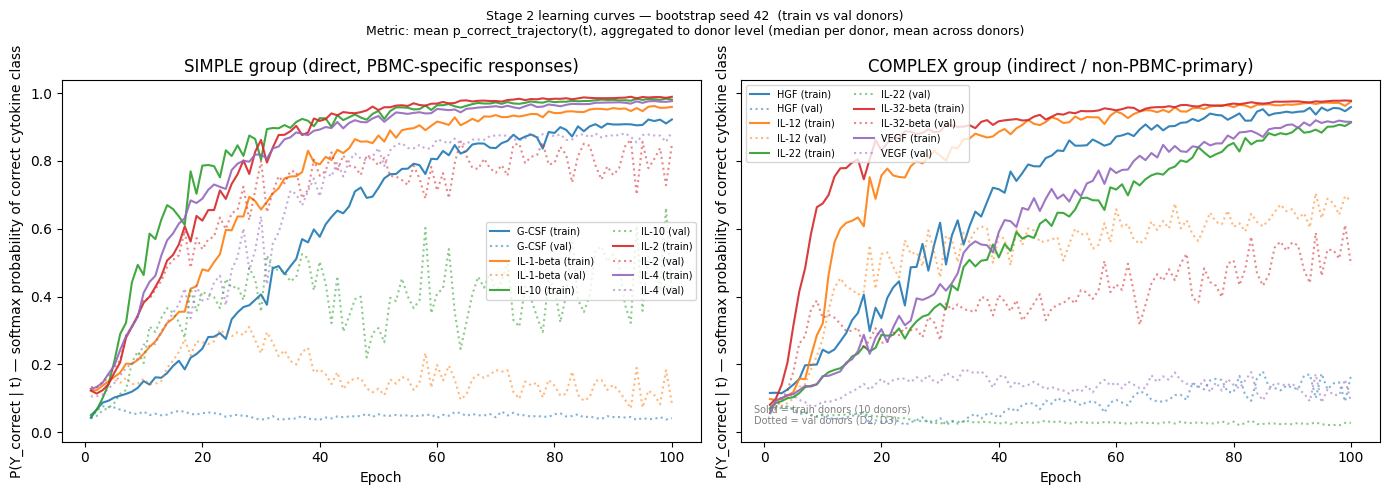

In [14]:
# Plot learning curves — train (solid) and val (dotted) in the same color per cytokine.
# Color distinguishes group: steelblue = SIMPLE, tomato = COMPLEX.
# A persistent train > val gap indicates the model is exploiting donor-specific expression.
_SIMPLE_COLOR  = "steelblue"
_COMPLEX_COLOR = "tomato"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
epochs = dynamics_stage2["logged_epochs"]
_tab10 = plt.cm.tab10.colors

for ax, group_cyts, group_label, base_color in zip(
    axes,
    [SIMPLE_CYTOKINES, COMPLEX_CYTOKINES],
    ["SIMPLE group (direct, PBMC-specific responses)", "COMPLEX group (indirect / non-PBMC-primary)"],
    [_SIMPLE_COLOR, _COMPLEX_COLOR],
):
    for ci, cyt in enumerate(group_cyts):
        color = _tab10[ci % len(_tab10)]
        if cyt in donor_traj:
            train_mean = np.mean(list(donor_traj[cyt].values()), axis=0)
            ax.plot(epochs, train_mean, color=color, linestyle="-",
                    alpha=0.9, label=f"{cyt} (train)")
        if cyt in val_donor_traj:
            val_mean = np.mean(list(val_donor_traj[cyt].values()), axis=0)
            ax.plot(epochs, val_mean, color=color, linestyle=":",
                    alpha=0.55, label=f"{cyt} (val)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("P(Y_correct | t) — softmax probability of correct cytokine class")
    ax.set_title(group_label)
    ax.legend(fontsize=7, ncol=2)

axes[1].annotate(
    "Solid = train donors (10 donors)\nDotted = val donors (D2, D3)",
    xy=(0.02, 0.05), xycoords="axes fraction", fontsize=7, color="gray",
)

plt.suptitle(
    f"Stage 2 learning curves — bootstrap seed {BOOTSTRAP_SEED}  (train vs val donors)\n"
    "Metric: mean p_correct_trajectory(t), aggregated to donor level "
    "(median per donor, mean across donors)",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(f"learning_curves_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

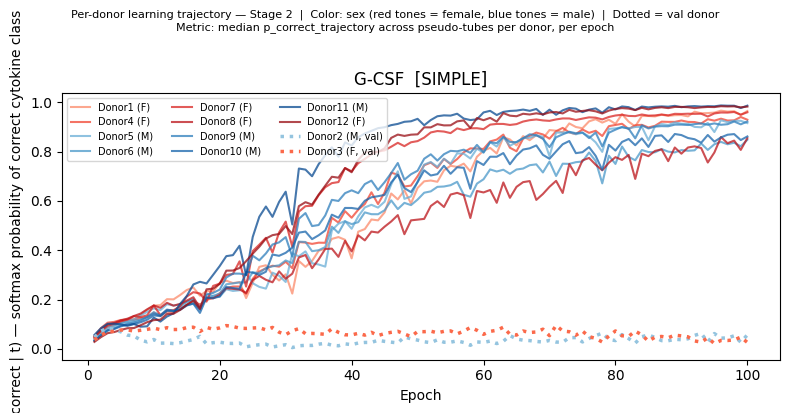

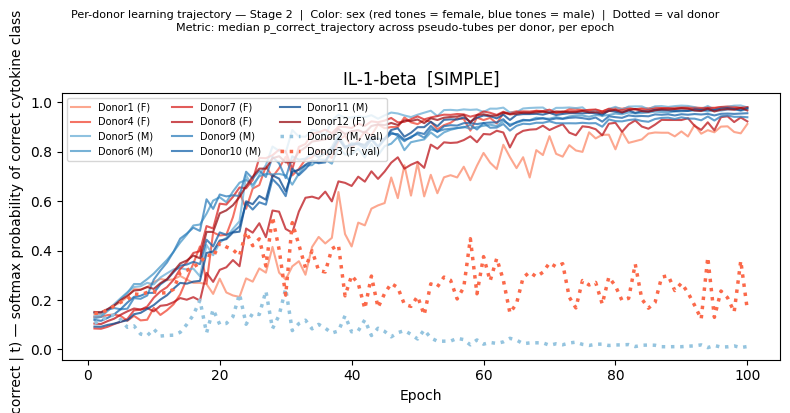

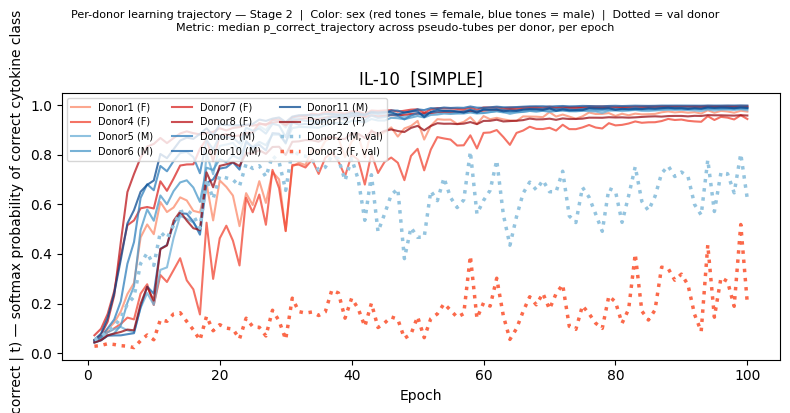

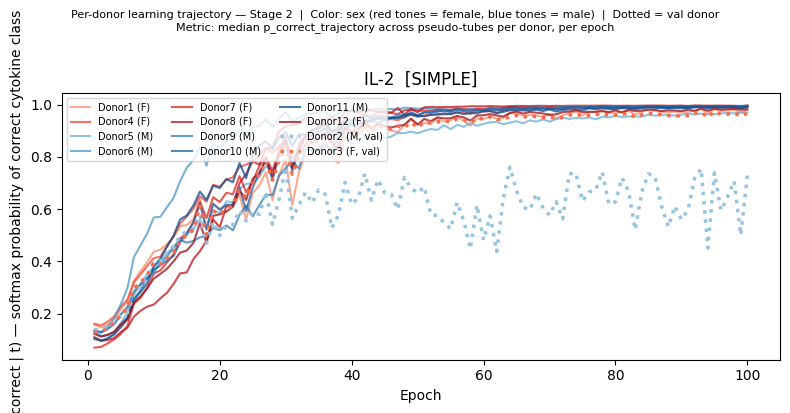

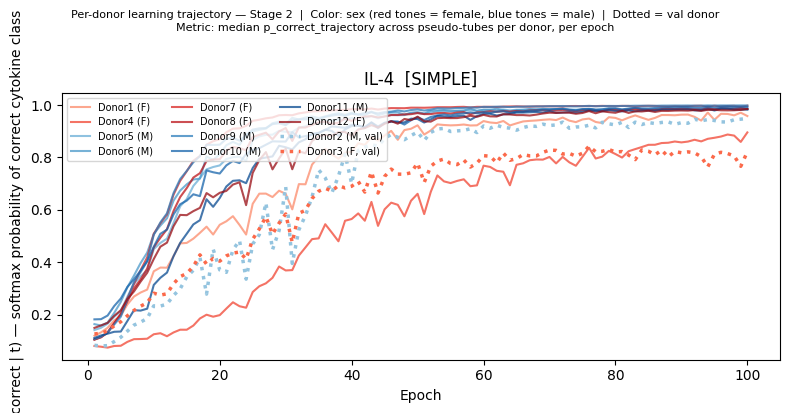

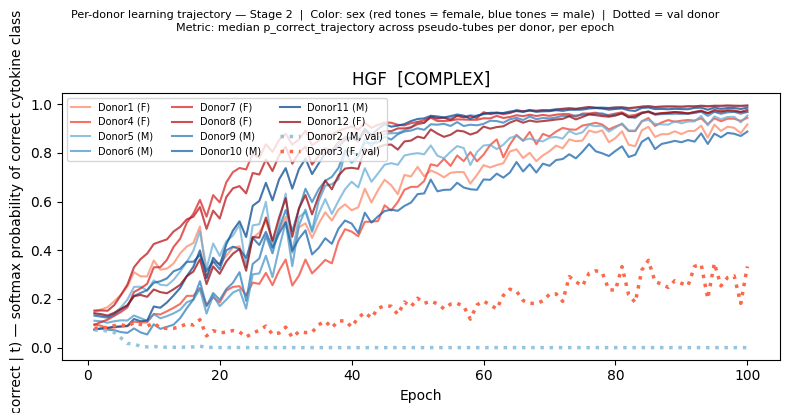

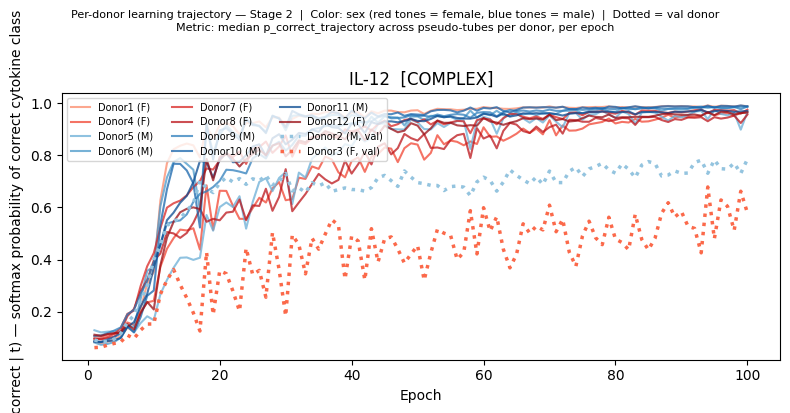

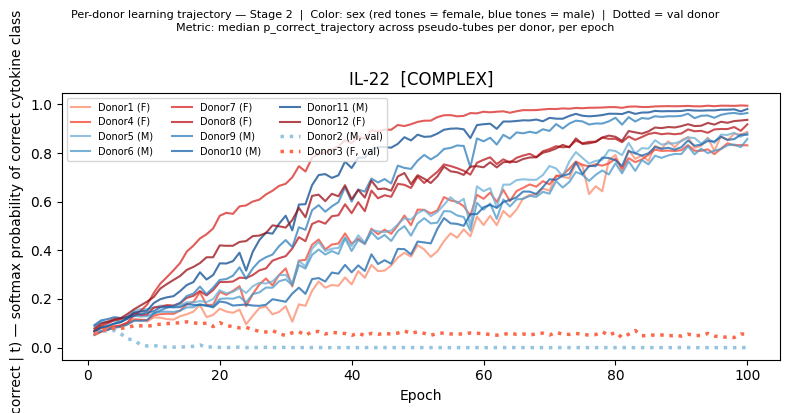

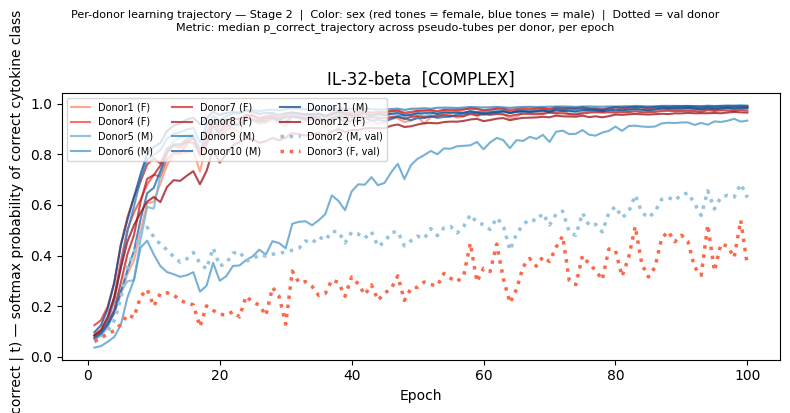

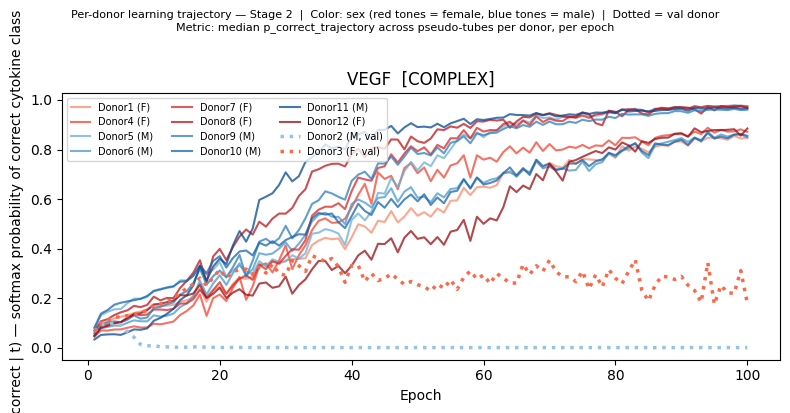

In [15]:
# Per-cytokine per-donor P(Y_correct) trajectories — colored by donor sex.
# Color encodes sex: red tones = female, blue tones = male.
# Linestyle encodes split: solid = train donor, dotted + thicker = val donor (D2, D3).

FEMALE_DONORS = {f"Donor{i}" for i in [1, 3, 4, 7, 8, 12]}
MALE_DONORS   = {f"Donor{i}" for i in [2, 5, 6, 9, 10, 11]}

_female_sorted = sorted(FEMALE_DONORS, key=lambda d: int(d.replace("Donor", "")))
_male_sorted   = sorted(MALE_DONORS,   key=lambda d: int(d.replace("Donor", "")))

_female_palette = plt.cm.Reds(np.linspace(0.4, 0.9, len(_female_sorted)))
_male_palette   = plt.cm.Blues(np.linspace(0.4, 0.9, len(_male_sorted)))

_donor_color = (
    {d: c for d, c in zip(_female_sorted, _female_palette)}
    | {d: c for d, c in zip(_male_sorted,   _male_palette)}
)

def _sex_label(donor):
    return "F" if donor in FEMALE_DONORS else "M"

_epochs = dynamics_stage2["logged_epochs"]

for cyt in SUBSET_CYTOKINES:
    group = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
    fig, ax = plt.subplots(figsize=(8, 4))

    for donor, traj in sorted(
        donor_traj.get(cyt, {}).items(), key=lambda x: int(x[0].replace("Donor", ""))
    ):
        ax.plot(_epochs, traj,
                color=_donor_color.get(donor, "gray"),
                linestyle="-", linewidth=1.5, alpha=0.75,
                label=f"{donor} ({_sex_label(donor)})")

    for donor, traj in sorted(
        val_donor_traj.get(cyt, {}).items(), key=lambda x: int(x[0].replace("Donor", ""))
    ):
        ax.plot(_epochs, traj,
                color=_donor_color.get(donor, "gray"),
                linestyle=":", linewidth=2.5, alpha=1.0,
                label=f"{donor} ({_sex_label(donor)}, val)")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("P(Y_correct | t) — softmax probability of correct cytokine class")
    ax.set_title(f"{cyt}  [{group}]")
    ax.legend(fontsize=7, ncol=3, loc="upper left")
    fig.suptitle(
        "Per-donor learning trajectory — Stage 2"
        "  |  Color: sex (red tones = female, blue tones = male)"
        "  |  Dotted = val donor\n"
        "Metric: median p_correct_trajectory across pseudo-tubes per donor, per epoch",
        fontsize=8, y=1.02,
    )
    plt.tight_layout()
    safe_name = cyt.replace("/", "_").replace(" ", "_")
    plt.savefig(f"per_donor_curves_{safe_name}_bootstrap_{BOOTSTRAP_SEED}.png", dpi=120, bbox_inches="tight")
    plt.show()

In [16]:
# Attention entropy summary — train and val
entropy_result     = compute_cytokine_entropy_summary(dynamics_stage2["records"])
val_entropy_result = compute_cytokine_entropy_summary(dynamics_stage2["val_records"])
entropy_summary     = entropy_result["summary"]
val_entropy_summary = val_entropy_result["summary"]

# Sort by train mean entropy (low=focused, high=pleiotropic)
entropy_sorted = sorted(entropy_summary.items(), key=lambda x: x[1]["mean_entropy"])

print("Cytokine attention entropy summary")
print(f"Metric: {entropy_result['metric_description']}")
print()
print(f"{'Cytokine':<20}  {'Train H':>10}  {'Val H':>8}  Group")
print("-" * 52)
for cyt, stats in entropy_sorted:
    group = "SIMPLE" if cyt in SIMPLE_CYTOKINES else ("COMPLEX" if cyt in COMPLEX_CYTOKINES else "PBS")
    val_h = val_entropy_summary.get(cyt, {}).get("mean_entropy", float("nan"))
    print(f"  {cyt:<20}  {stats['mean_entropy']:>10.3f}  {val_h:>8.3f}  {group}")

Cytokine attention entropy summary
Metric: mean across epochs and pseudo-tubes of H(attention_weights) = -sum_i a_i * log(a_i), aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

Cytokine                 Train H     Val H  Group
----------------------------------------------------
  HGF                        2.344     3.242  COMPLEX
  VEGF                       2.504     2.881  COMPLEX
  PBS                        2.592     3.013  PBS
  IL-32-beta                 2.592     2.889  COMPLEX
  IL-10                      2.634     2.970  SIMPLE
  IL-22                      2.712     3.021  COMPLEX
  IL-2                       2.831     3.004  SIMPLE
  G-CSF                      2.873     3.057  SIMPLE
  IL-4                       2.935     3.008  SIMPLE
  IL-1-beta                  2.996     2.896  SIMPLE
  IL-12                      3.019     3.281  COMPLEX


In [17]:
# Confusion entropy summary — train and val
confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["confusion_entropy_trajectory"], exclude=["PBS"]
)
val_confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["val_confusion_entropy_trajectory"], exclude=["PBS"]
)
val_conf_map = {cyt: auc for cyt, auc in val_confusion_result["ranking"]}

print("Cytokine confusion entropy ranking")
print(f"Metric: {confusion_result['metric_description']}")
print()
print(f"{'Cytokine':<20}  {'Train AUC(H_c)':>14}  {'Val AUC(H_c)':>12}  Group")
print("-" * 64)
for cyt, auc in confusion_result["ranking"]:
    group = "SIMPLE" if cyt in SIMPLE_CYTOKINES else ("COMPLEX" if cyt in COMPLEX_CYTOKINES else "PBS")
    val_auc = val_conf_map.get(cyt, float("nan"))
    print(f"  {cyt:<20}  {auc:>14.3f}  {val_auc:>12.3f}  {group}")

Cytokine confusion entropy ranking
Metric: AUC of H_confusion(C,t) = -sum_{k!=C} q_k(t) * log(q_k(t)), where q_k(t) is the renormalized off-diagonal mean softmax score across all pseudo-tubes of cytokine C at epoch t. Low = confusion concentrated on similar cytokines (similarity confound). High = confusion spread randomly (genuine difficulty).

Cytokine              Train AUC(H_c)  Val AUC(H_c)  Group
----------------------------------------------------------------
  IL-1-beta                    203.874       170.593  SIMPLE
  IL-4                         195.024       200.691  SIMPLE
  IL-2                         186.012       107.716  SIMPLE
  G-CSF                        184.027       175.095  SIMPLE
  IL-12                        162.764       176.339  COMPLEX
  IL-22                        159.683       209.393  COMPLEX
  IL-32-beta                   151.452       117.763  COMPLEX
  VEGF                         150.745       193.766  COMPLEX
  IL-10                        146.302

## 6. Hypothesis Test

**Pre-registered hypothesis:** simple cytokines rank higher in learnability AUC than complex cytokines.

Tested with a **one-sided Mann-Whitney U test** (alternative: simple > complex) on the
5 simple vs 5 complex per-cytokine learnability AUC values (donor-aggregated, train donors).

⚠️ With n=5 per group the test has low power. Report effect size (rank-biserial r) alongside p.

In [18]:
# Mann-Whitney U — one-sided: alternative = simple > complex
auc_map = {cyt: auc for cyt, auc in ranking}
simple_auc_vals  = [auc_map[c] for c in SIMPLE_CYTOKINES  if c in auc_map]
complex_auc_vals = [auc_map[c] for c in COMPLEX_CYTOKINES if c in auc_map]

u_stat, p_one_sided = mannwhitneyu(simple_auc_vals, complex_auc_vals, alternative="greater")

# Rank-biserial correlation: r = 1 - 2U / (n1 * n2)
n1, n2 = len(simple_auc_vals), len(complex_auc_vals)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print("Hypothesis test — Stage 2 (train donors)")
print(f"Bootstrap seed: {BOOTSTRAP_SEED}")
print()
print(f"  SIMPLE  AUCs: {[f'{x:.3f}' for x in sorted(simple_auc_vals, reverse=True)]}")
print(f"  COMPLEX AUCs: {[f'{x:.3f}' for x in sorted(complex_auc_vals, reverse=True)]}")
print()
print(f"  Mann-Whitney U statistic: {u_stat:.1f}")
print(f"  One-sided p-value (simple > complex): {p_one_sided:.4f}")
print(f"  Rank-biserial correlation r = {r_rb:.3f}")
print(f"    r > 0: simple group tends to have higher AUC  (1 = perfect separation)")
print()
alpha = 0.05
if p_one_sided < alpha:
    print(f"  Result: p < {alpha} → hypothesis SUPPORTED (simple > complex, train donors)")
else:
    print(f"  Result: p >= {alpha} → hypothesis NOT SUPPORTED at alpha={alpha}")
print()
print("  Note: n=5 per group → low power. Report effect size alongside p-value.")
print("  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.")

# Val donors version (informative only — not a separate hypothesis test)
val_auc_vals_simple  = [val_auc_map.get(c, float("nan")) for c in SIMPLE_CYTOKINES]
val_auc_vals_complex = [val_auc_map.get(c, float("nan")) for c in COMPLEX_CYTOKINES]
val_auc_vals_simple  = [x for x in val_auc_vals_simple  if not np.isnan(x)]
val_auc_vals_complex = [x for x in val_auc_vals_complex if not np.isnan(x)]
if val_auc_vals_simple and val_auc_vals_complex:
    u_val, p_val = mannwhitneyu(val_auc_vals_simple, val_auc_vals_complex, alternative="greater")
    r_val = 1 - (2 * u_val) / (len(val_auc_vals_simple) * len(val_auc_vals_complex))
    print()
    print(f"  Val donors (D2, D3) — informative only:")
    print(f"    One-sided p = {p_val:.4f}  |  rank-biserial r = {r_val:.3f}")

Hypothesis test — Stage 2 (train donors)
Bootstrap seed: 42

  SIMPLE  AUCs: ['83.704', '81.543', '81.105', '73.160', '60.624']
  COMPLEX AUCs: ['86.259', '80.580', '68.654', '60.315', '56.928']

  Mann-Whitney U statistic: 17.0
  One-sided p-value (simple > complex): 0.2103
  Rank-biserial correlation r = -0.360
    r > 0: simple group tends to have higher AUC  (1 = perfect separation)

  Result: p >= 0.05 → hypothesis NOT SUPPORTED at alpha=0.05

  Note: n=5 per group → low power. Report effect size alongside p-value.
  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.

  Val donors (D2, D3) — informative only:
    One-sided p = 0.2103  |  rank-biserial r = -0.360


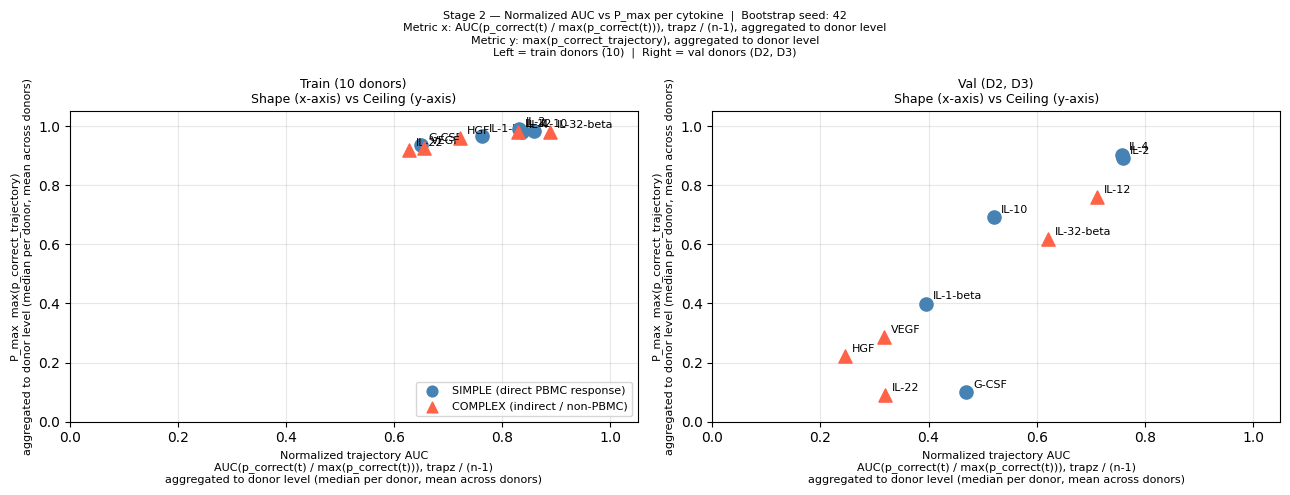

In [19]:
# Scatter: Normalized AUC vs Pmax (train and val splits side by side)
# x-axis: shape of learning — how quickly the model reached its ceiling (NormAUC)
# y-axis: gate metric     — how high the ceiling was (Pmax)
# Color: steelblue = SIMPLE, tomato = COMPLEX

_group_color  = {"SIMPLE": "steelblue", "COMPLEX": "tomato"}
_group_marker = {"SIMPLE": "o",         "COMPLEX": "^"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (split_label, extra_dict) in zip(axes, [
    ("Train (10 donors)", extra_train),
    ("Val (D2, D3)",      extra_val),
]):
    for cyt in SUBSET_CYTOKINES:
        if cyt not in extra_dict:
            continue
        m     = extra_dict[cyt]
        group = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
        ax.scatter(
            m["norm_auc"], m["pmax"],
            color=_group_color[group], marker=_group_marker[group],
            s=90, zorder=3,
        )
        ax.annotate(cyt, (m["norm_auc"], m["pmax"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)

    ax.set_xlabel(
        "Normalized trajectory AUC\n"
        "AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1)\n"
        "aggregated to donor level (median per donor, mean across donors)",
        fontsize=8,
    )
    ax.set_ylabel(
        "P_max  max(p_correct_trajectory)\n"
        "aggregated to donor level (median per donor, mean across donors)",
        fontsize=8,
    )
    ax.set_title(
        f"{split_label}\nShape (x-axis) vs Ceiling (y-axis)",
        fontsize=9,
    )
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

legend_handles = [
    plt.scatter([], [], color=_group_color["SIMPLE"],  marker=_group_marker["SIMPLE"],
                s=60, label="SIMPLE (direct PBMC response)"),
    plt.scatter([], [], color=_group_color["COMPLEX"], marker=_group_marker["COMPLEX"],
                s=60, label="COMPLEX (indirect / non-PBMC)"),
]
axes[0].legend(handles=legend_handles, fontsize=8, loc="lower right")

plt.suptitle(
    f"Stage 2 — Normalized AUC vs P_max per cytokine  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Metric x: AUC(p_correct(t) / max(p_correct(t))), trapz / (n-1), aggregated to donor level\n"
    "Metric y: max(p_correct_trajectory), aggregated to donor level\n"
    "Left = train donors (10)  |  Right = val donors (D2, D3)",
    fontsize=8,
)
plt.tight_layout()
plt.savefig(f"scatter_normauc_pmax_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Validation

In [20]:
# --- Donor-level generalization check (see CLAUDE.md Section 16) ---
# Val donors D2 and D3 were selected as the most biologically distinct donors:
#   D3: highest baseline ISG expression (worst-case IFN generalization test)
#   D2: aberrant CD14 Mono baseline resembling IL-32-β-stimulated state
# Neither donor contributed any gradient updates to the model.

train_ranking_list = rank_cytokines_by_learnability(donor_traj,     exclude=["PBS"])["ranking"]
val_ranking_list   = rank_cytokines_by_learnability(val_donor_traj, exclude=["PBS"])["ranking"]

train_order = [c for c, _ in train_ranking_list]
val_order   = [c for c, _ in val_ranking_list]
val_rank_by_cyt = {c: i for i, c in enumerate(val_order)}
val_ranks_aligned = [val_rank_by_cyt[c] for c in train_order]

rho, pval = spearmanr(range(len(train_order)), val_ranks_aligned)

print(f"Donor-level generalization check — Stage 2  |  Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"  Train donors: {sorted({e['donor'] for e in train_manifest})}")
print(f"  Val donors:   {VAL_DONORS}  (never used in optimizer steps)")
print()
print(f"  Train/val rank correlation: Spearman rho = {rho:.3f}  (p={pval:.3f})")
print(f"  Stable (rho > 0.7): {rho > 0.7}")
print()
print("  Per-cytokine AUC (Train vs Val):")
print(f"  {'Cytokine':<20}  {'Train AUC':>10}  {'Val AUC':>9}  {'Ratio V/T':>10}  Group")
print("  " + "-" * 64)
val_auc_map2 = {c: a for c, a in val_ranking_list}
for cyt, train_auc in train_ranking_list:
    val_auc = val_auc_map2.get(cyt, float("nan"))
    ratio   = val_auc / train_auc if train_auc > 0 else float("nan")
    group   = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
    flag    = "  ← possible overfit" if ratio < 0.6 else ""
    print(f"  {cyt:<20}  {train_auc:>10.3f}  {val_auc:>9.3f}  {ratio:>10.2f}  {group}{flag}")
print()
print("  Interpretation:")
print("    V/T ratio ≈ 1.0 → cytokine program generalizes to held-out donors.")
print("    V/T ratio << 1  → model may be exploiting donor-specific expression patterns.")

Donor-level generalization check — Stage 2  |  Bootstrap seed: 42
  Train donors: ['Donor1', 'Donor10', 'Donor11', 'Donor12', 'Donor4', 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']
  Val donors:   ['Donor2', 'Donor3']  (never used in optimizer steps)

  Train/val rank correlation: Spearman rho = 0.782  (p=0.008)
  Stable (rho > 0.7): True

  Per-cytokine AUC (Train vs Val):
  Cytokine               Train AUC    Val AUC   Ratio V/T  Group
  ----------------------------------------------------------------
  IL-32-beta                86.259     38.571        0.45  COMPLEX  ← possible overfit
  IL-10                     83.704     38.143        0.46  SIMPLE  ← possible overfit
  IL-2                      81.543     68.068        0.83  SIMPLE
  IL-4                      81.105     67.090        0.83  SIMPLE
  IL-12                     80.580     52.784        0.66  COMPLEX
  IL-1-beta                 73.160     16.960        0.23  SIMPLE  ← possible overfit
  HGF                       

In [21]:
# Seed stability — run with all three seeds from config
# NOTE: Pre-register your directional predictions BEFORE looking at these results.

all_dynamics = [dynamics_stage2]  # Add dynamics from other seeds here

# Example: to run with additional seeds, re-run train_mil with seed=123 and seed=7
# and append to all_dynamics.

if len(all_dynamics) > 1:
    stability = check_seed_stability(all_dynamics, exclude=["PBS"])
    print(f"Mean Spearman rho across seeds: {stability['mean_rho']:.3f}")
    print(f"Stable ordering: {stability['stable']}")
else:
    print("Run with multiple seeds to assess stability. See config random_seeds.")

Run with multiple seeds to assess stability. See config random_seeds.


In [22]:
# Stage 2 vs Stage 3 ranking correlation — train and val
donor_traj_s3     = aggregate_to_donor_level(dynamics_stage3["records"])
val_donor_traj_s3 = aggregate_to_donor_level(dynamics_stage3["val_records"])

ranking_s3     = rank_cytokines_by_learnability(donor_traj_s3,     exclude=["PBS"])
val_ranking_s3 = rank_cytokines_by_learnability(val_donor_traj_s3, exclude=["PBS"])

stability_s2_s3 = check_seed_stability(
    [dynamics_stage2, dynamics_stage3], exclude=["PBS"]
)
print("Stage 2 vs Stage 3 ranking correlation")
print(
    "Metric: Spearman rho between cytokine learnability rankings "
    "(AUC of donor-level p_correct_trajectory, median per donor, mean across donors)"
)
print(f"  Train: Spearman rho = {stability_s2_s3['mean_rho']:.3f}")
print(f"  Stable across stages (rho > 0.7): {stability_s2_s3['stable']}")

val_s2_order = [c for c, _ in val_learnability_result["ranking"]]
val_s3_order = [c for c, _ in val_ranking_s3["ranking"]]
if set(val_s2_order) == set(val_s3_order):
    val_s3_aligned = [val_s3_order.index(c) for c in val_s2_order]
    rho_val, _ = spearmanr(range(len(val_s2_order)), val_s3_aligned)
    print(f"  Val:   Spearman rho = {rho_val:.3f}")

Stage 2 vs Stage 3 ranking correlation
Metric: Spearman rho between cytokine learnability rankings (AUC of donor-level p_correct_trajectory, median per donor, mean across donors)
  Train: Spearman rho = 0.830
  Stable across stages (rho > 0.7): True
  Val:   Spearman rho = 0.867


In [23]:
# Known functional groupings — within-group consistency check
# Cytokines from the same pool should show similar learnability profiles.
# This is a diagnostic, not an additional hypothesis test.
sampled_groups = {
    "simple_sampled": SIMPLE_CYTOKINES,
    "complex_sampled": COMPLEX_CYTOKINES,
}

grouping_result = check_functional_groupings(donor_traj, sampled_groups)
for group, result in grouping_result.items():
    print(f"\n{group}:")
    for k, v in result.items():
        print(f"  {k}: {v}")


simple_sampled:
  members_found: ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4']
  within_auc_std: 8.492699198316139
  between_auc_std: 10.392331275549417
  passes: True

complex_sampled:
  members_found: ['HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']
  within_auc_std: 11.325049390915451
  between_auc_std: 7.814914834792097
  passes: False


## 8. Cell-type Stratified Instance Confidence Analysis

Post-hoc reintroduction of cell type labels to detect cascade ordering:
which cell types activate early vs. late across training epochs.

Cell type labels were **never** passed to the model during training.
They are loaded here from the original  files and used only for post-hoc grouping.

**Metric:** Mean C_i(t) = a_i(t) × P(t)(Y_correct), grouped by cell type,
aggregated to donor level (median across pseudo-tubes per donor, then mean across donors).

- **Early activation** → Primary Anchor (direct, canonical target cell type)
- **Late / sequential activation** → Secondary Relay (cascade-dependent)
- **No activation** → cell type not detectably involved within training window

In [24]:
import anndata as ad

# Load cell type labels post-hoc from h5ad files.
# Cell type labels were NEVER used during training -- reintroduced only here
# for post-hoc cascade analysis. This is the standard post-hoc MIL workflow.
print("Loading cell type labels from pseudo-tube h5ad files (post-hoc only)...")
cell_type_obs = {}
all_records = dynamics_stage2["records"] + dynamics_stage2["val_records"]
for rec in all_records:
    path = rec["tube_path"]
    if path not in cell_type_obs:
        _adata = ad.read_h5ad(path, backed="r")
        cell_type_obs[path] = _adata.obs["cell_type"].values.copy()
        _adata.file.close()

_all_cts = sorted({ct for labels in cell_type_obs.values() for ct in labels})
print(f"Loaded {len(cell_type_obs)} tubes; {len(_all_cts)} unique cell types:")
print(_all_cts)

Loading cell type labels from pseudo-tube h5ad files (post-hoc only)...
Loaded 1320 tubes; 18 unique cell types:
['B Intermediate/Memory', 'B Naive', 'CD14 Mono', 'CD16 Mono', 'CD4 Memory', 'CD4 Naive', 'CD8 Memory', 'CD8 Naive', 'HSPC', 'ILC', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Plasmablast', 'Treg', 'cDC', 'pDC']


In [25]:
# Inlined from cytokine_mil/analysis/dynamics.py
# (avoids needing to reinstall the package to get the new functions)
from collections import defaultdict

def compute_celltype_confidence_trajectories(records, cell_type_obs, cytokine_name):
    """
    Compute mean C_i(t) per cell type over training epochs for one cytokine.

    Cell type labels are re-introduced post-hoc -- never passed to the model.
    Aggregation: median across pseudo-tubes per donor, then mean across donors.

    Returns:
        dict: {cell_type -> np.array(n_logged_epochs)}
    """
    import numpy as _np
    cyt_records = [r for r in records if r["cytokine"] == cytokine_name]
    if not cyt_records:
        return {}

    raw = defaultdict(lambda: defaultdict(list))
    for rec in cyt_records:
        conf = rec.get("instance_confidence_trajectory")
        if conf is None:
            continue
        ct_labels = cell_type_obs.get(rec["tube_path"])
        if ct_labels is None:
            continue
        for ct in _np.unique(ct_labels):
            mask = ct_labels == ct
            mean_traj = conf[mask].mean(axis=0)  # (n_logged_epochs,)
            raw[str(ct)][rec["donor"]].append(mean_traj)

    result = {}
    for ct, donors in raw.items():
        donor_trajs = []
        for _donor, trajs in donors.items():
            donor_traj = _np.median(_np.stack(trajs), axis=0)
            donor_trajs.append(donor_traj)
        result[ct] = _np.mean(_np.stack(donor_trajs), axis=0)
    return result


def compute_celltype_activation_epoch(celltype_confidence_curves, threshold=0.1):
    """
    Find the first epoch index where each cell type's mean confidence crosses threshold.

    Args:
        celltype_confidence_curves: {cell_type -> np.array(n_epochs)}
        threshold: default 0.1
    Returns:
        {cell_type -> int epoch_index or None}
    """
    import numpy as _np
    result = {}
    for ct, traj in celltype_confidence_curves.items():
        indices = _np.where(_np.asarray(traj) >= threshold)[0]
        result[ct] = int(indices[0]) if len(indices) > 0 else None
    return result

In [26]:
def plot_celltype_confidence_trajectories(
    instance_confidence_trajectory,
    cell_type_labels,
    cytokine_name,
    logged_epochs=None,
    group=None,
    ax=None,
    figsize=(9, 4),
):
    """
    Plot mean instance confidence per cell type over training epochs for one cytokine.

    Cell types are post-hoc annotations re-introduced from the original .h5ad files.
    Never passed to the model during training.

    Aggregation: median across pseudo-tubes per donor, then mean across donors.
    Metric: mean C_i(t) = a_i(t) * P(t)(Y_correct), grouped by cell type,
    aggregated to donor level (median per donor, mean across donors).

    Args:
        instance_confidence_trajectory: records list from train_mil() dynamics output.
        cell_type_labels: dict mapping tube_path -> (N,) cell type label array.
        cytokine_name: cytokine to plot.
        logged_epochs: list of epoch indices (x-axis). Inferred if None.
        group: 'SIMPLE', 'COMPLEX', or None -- used only in subplot title.
        ax: optional existing Axes; creates a new figure if None.
        figsize: figure size used when ax is None.
    Returns:
        dict: {cell_type: np.array(n_epochs)} -- donor-aggregated trajectories.
    """
    ct_curves = compute_celltype_confidence_trajectories(
        instance_confidence_trajectory, cell_type_labels, cytokine_name
    )
    if not ct_curves:
        print(f"No cell type confidence data for {cytokine_name}.")
        return {}

    if logged_epochs is None:
        n_ep = next(iter(ct_curves.values())).shape[0]
        logged_epochs = list(range(n_ep))

    _created_fig = ax is None
    if _created_fig:
        fig, ax = plt.subplots(figsize=figsize)

    _cmap = plt.cm.tab20.colors
    for i, (ct, traj) in enumerate(sorted(ct_curves.items())):
        ax.plot(logged_epochs, traj,
                color=_cmap[i % len(_cmap)], linewidth=1.5, label=ct)

    ax.set_xlabel("Epoch")
    ax.set_ylabel(
        "Mean C_i(t) = a_i(t) * P(t)(Y_correct) "
        "[aggregated to donor level: median per donor, mean across donors]"
    )
    _group_label = f"  [{group}]" if group else ""
    ax.set_title(f"{cytokine_name}{_group_label}")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    ax.grid(alpha=0.25)

    if _created_fig:
        fig.suptitle(
            "Cell-type stratified instance confidence trajectory  |  "
            "Metric: mean C_i(t) = a_i(t) * P(t)(Y_correct), grouped by cell type, "
            "aggregated to donor level (median per donor, mean across donors)",
            fontsize=8, y=1.02,
        )
        plt.tight_layout()
        _safe = cytokine_name.replace("/", "_").replace(" ", "_")
        plt.savefig(
            f"celltype_confidence_{_safe}_bootstrap_{BOOTSTRAP_SEED}.png",
            dpi=120, bbox_inches="tight",
        )
        plt.show()

    return ct_curves

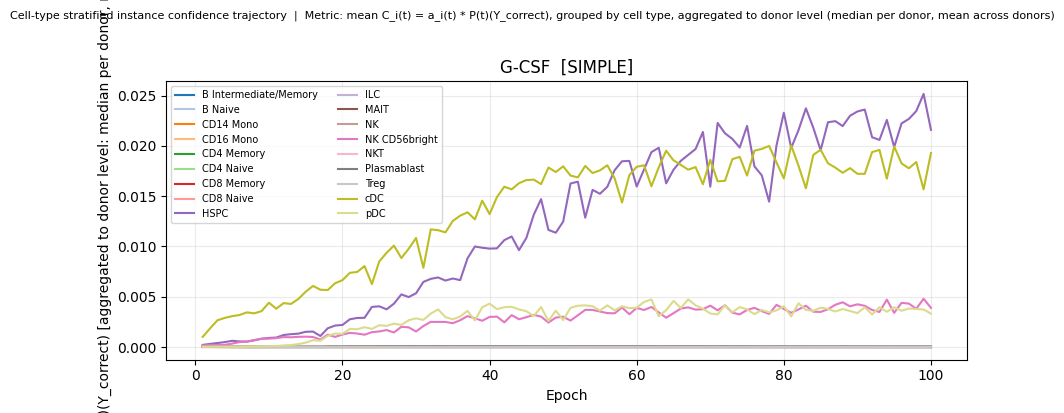

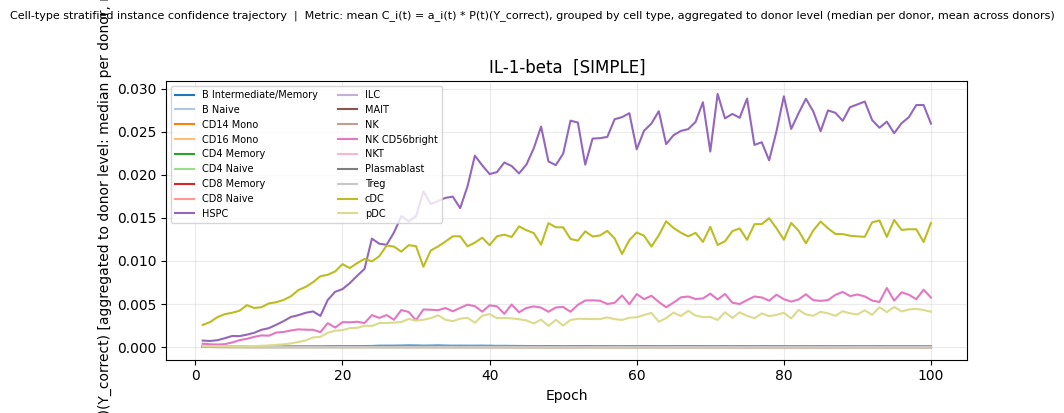

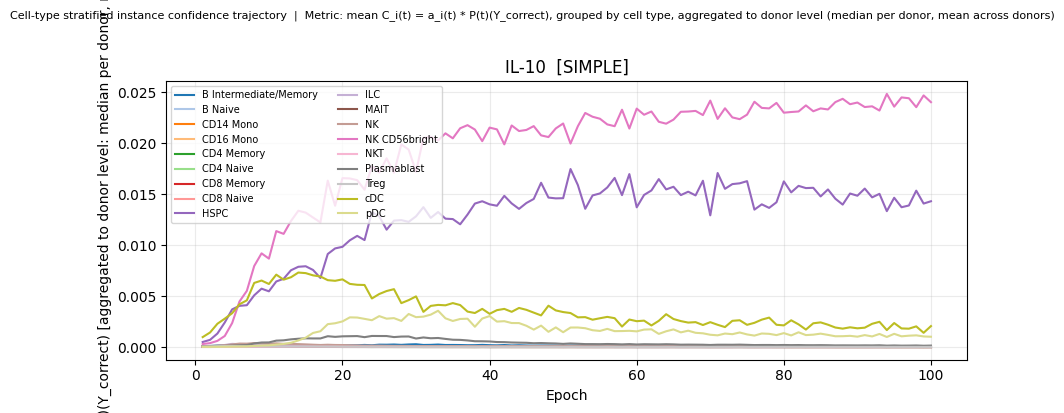

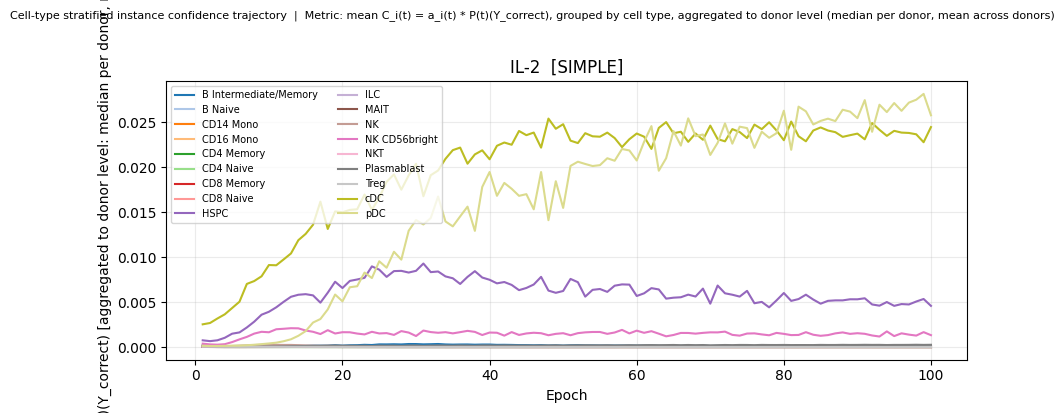

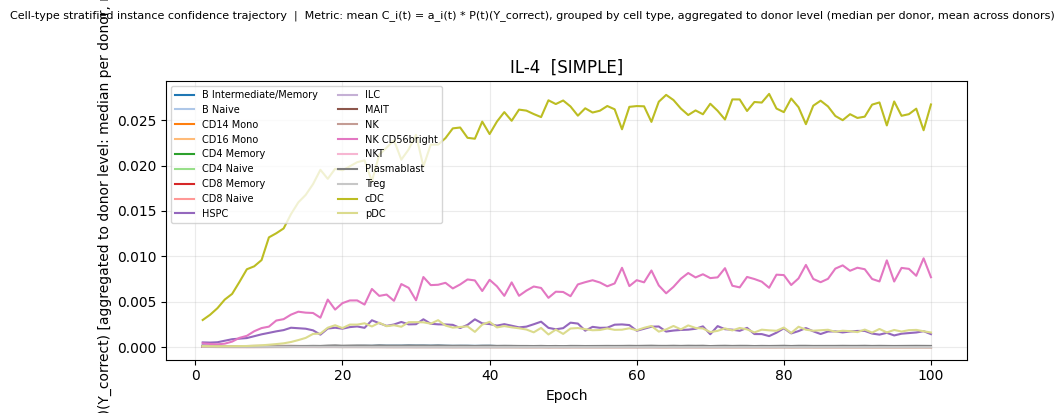

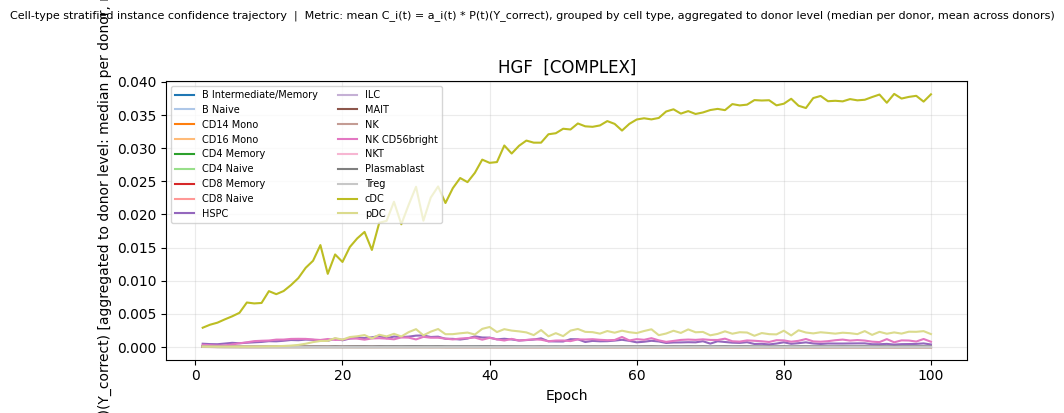

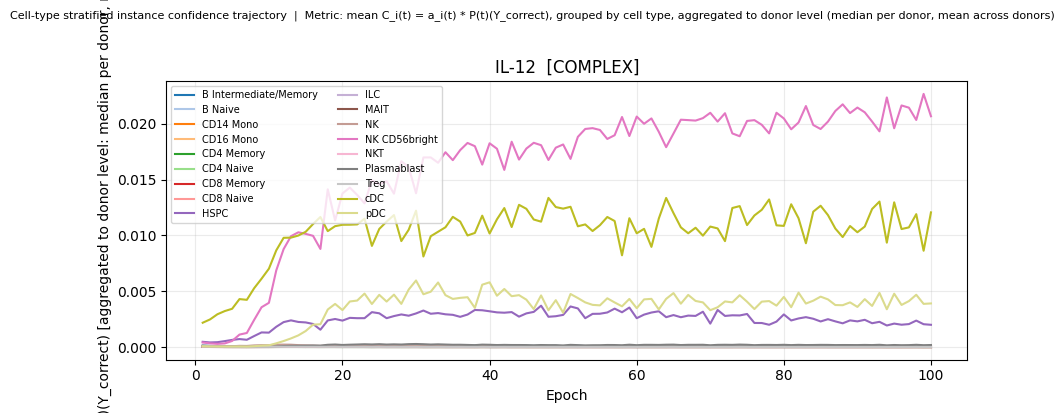

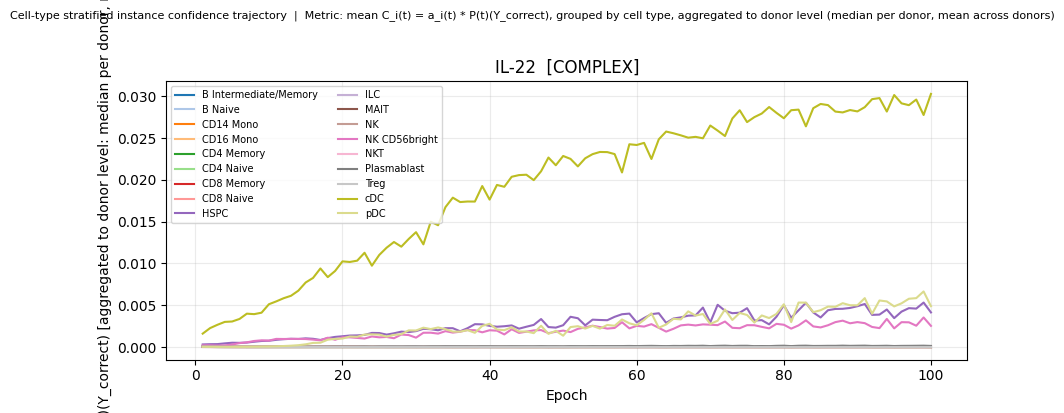

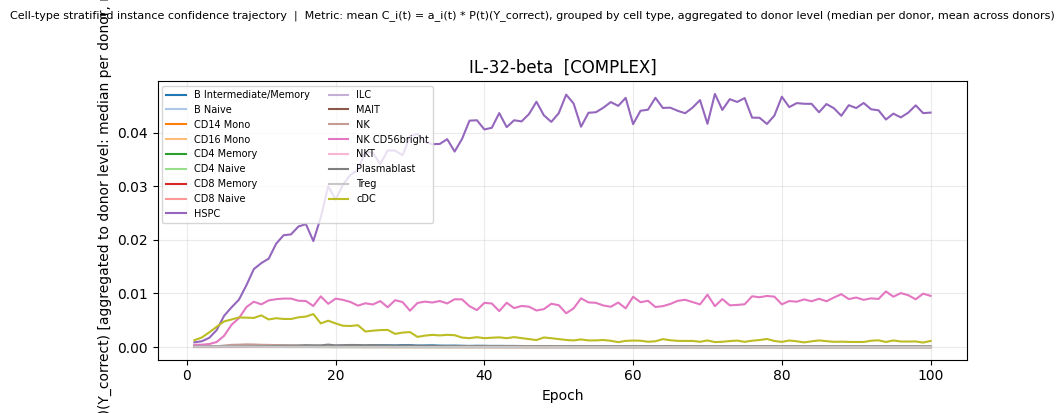

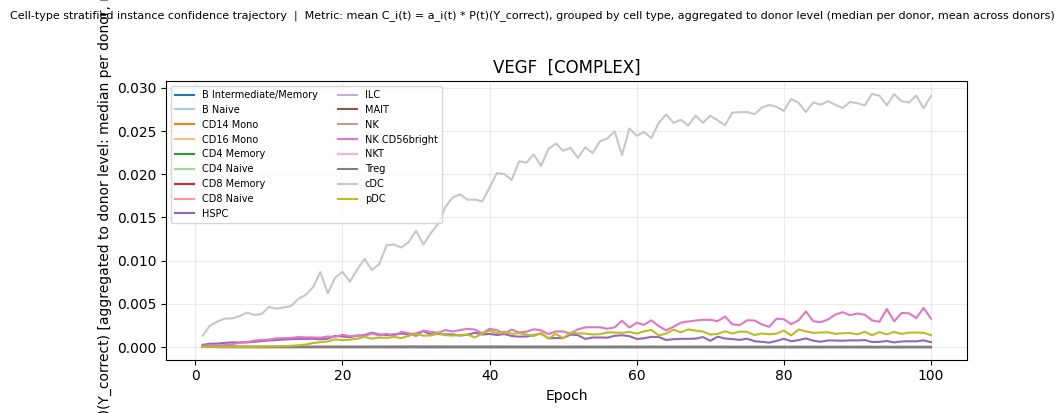

In [27]:
# Per-cytokine cell-type confidence trajectories — train donors, Stage 2
# Each line is one cell type; y-axis is mean C_i(t) aggregated to donor level.
# Early-rising lines = primary responders; late-rising lines = secondary relays.
_epochs = dynamics_stage2["logged_epochs"]

for cyt in SUBSET_CYTOKINES:
    _grp = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
    plot_celltype_confidence_trajectories(
        dynamics_stage2["records"],
        cell_type_obs,
        cyt,
        logged_epochs=_epochs,
        group=_grp,
    )

In [28]:
def plot_celltype_activation_heatmap(
    records,
    cell_type_obs,
    cytokines,
    logged_epochs,
    threshold=0.1,
    figsize=(14, 7),
):
    """
    Heatmap of cell-type activation epoch across cytokines.

    Rows = cytokines (ordered by learnability rank).
    Columns = cell types.
    Color = first training epoch at which mean C_i(t) crosses threshold.
    Dash (em-dash) = never crossed within training window.

    Interpretation:
      Dark (early epoch)  -> wide cascade: many cell types activate early.
      Light (late epoch)  -> deep cascade: sequential, late activation.
      Many dashes         -> simple cytokine: few cell types detectably involved.

    Metric: first epoch index where mean C_i(t) >= threshold,
    grouped by cell type, aggregated to donor level (median per donor, mean across donors).

    Args:
        records: dynamics['records'] list.
        cell_type_obs: dict tube_path -> cell_type label array.
        cytokines: ordered list of cytokine names (y-axis rows).
        logged_epochs: list of epoch indices (used for colorbar ticks and annotations).
        threshold: confidence threshold for activation epoch detection.
        figsize: figure size.
    Returns:
        tuple: (activation_result, ct_curves_by_cyt)
            activation_result: {cytokine: {cell_type: epoch_index or None}}
            ct_curves_by_cyt:  {cytokine: {cell_type: np.array(n_epochs)}}
    """
    all_ct = set()
    ct_curves_by_cyt = {}
    for cyt in cytokines:
        curves = compute_celltype_confidence_trajectories(records, cell_type_obs, cyt)
        ct_curves_by_cyt[cyt] = curves
        all_ct.update(curves.keys())
    all_ct = sorted(all_ct)

    activation_result = {}
    for cyt in cytokines:
        activation_result[cyt] = compute_celltype_activation_epoch(
            ct_curves_by_cyt[cyt], threshold=threshold
        )

    # Build (cytokines x cell_types) matrix -- values = actual epoch number
    matrix = np.full((len(cytokines), len(all_ct)), np.nan)
    for i, cyt in enumerate(cytokines):
        for j, ct in enumerate(all_ct):
            ep_idx = activation_result[cyt].get(ct)
            if ep_idx is not None:
                matrix[i, j] = logged_epochs[ep_idx]

    fig, ax = plt.subplots(figsize=figsize)
    _vmin = np.nanmin(matrix) if not np.all(np.isnan(matrix)) else 0
    _vmax = np.nanmax(matrix) if not np.all(np.isnan(matrix)) else 1
    im = ax.imshow(
        matrix, aspect="auto", cmap="YlOrRd_r",
        vmin=_vmin, vmax=_vmax, interpolation="nearest",
    )
    plt.colorbar(im, ax=ax, label="First epoch crossing threshold (earlier = darker)")

    ax.set_xticks(range(len(all_ct)))
    ax.set_xticklabels(all_ct, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(cytokines)))
    _ylabels = [
        f"{cyt}  [SIMPLE]" if cyt in SIMPLE_CYTOKINES else f"{cyt}  [COMPLEX]"
        for cyt in cytokines
    ]
    ax.set_yticklabels(_ylabels, fontsize=8)
    ax.set_xlabel("Cell type")
    ax.set_ylabel("Cytokine  (ordered by learnability AUC, high to low)")

    for i in range(len(cytokines)):
        for j in range(len(all_ct)):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, str(int(val)),
                        ha="center", va="center", fontsize=6, color="black")
            else:
                ax.text(j, i, "--",
                        ha="center", va="center", fontsize=7, color="gray")

    fig.suptitle(
        f"Cell-type activation epoch heatmap  |  Bootstrap seed: {BOOTSTRAP_SEED}  |  "
        f"threshold={threshold}  |  "
        "Metric: first epoch where mean C_i(t) >= threshold, "
        "grouped by cell type, aggregated to donor level  |  "
        "Dark = primary responder  /  Light = secondary relay  /  -- = not activated",
        fontsize=8, y=1.03,
    )
    plt.tight_layout()
    plt.savefig(
        f"celltype_activation_heatmap_bootstrap_{BOOTSTRAP_SEED}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

    return activation_result, ct_curves_by_cyt

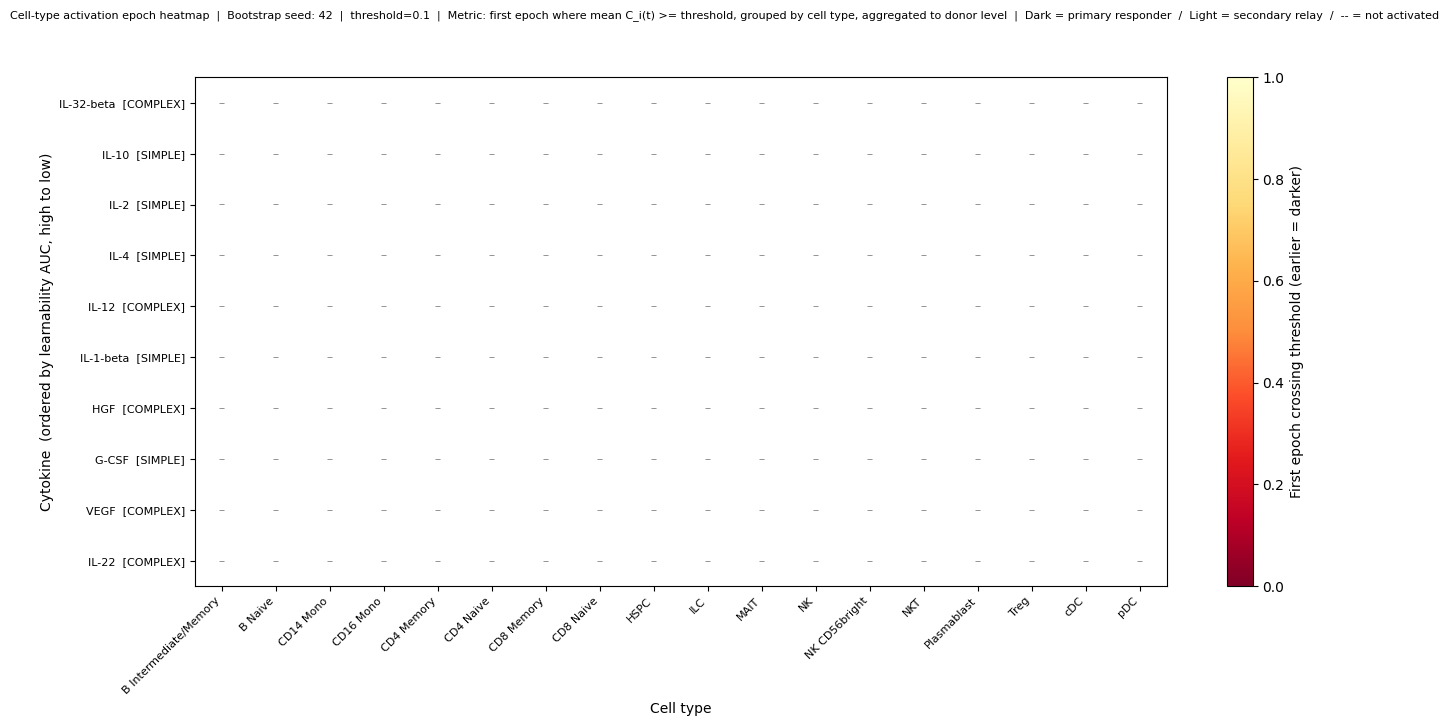

Cell-type cascade ordering — Stage 2, train donors  |  Bootstrap seed: 42
Metric: first epoch index where mean C_i(t) >= 0.1
(None = confidence never crossed threshold within training)

  IL-32-beta           [COMPLEX]    [not activated: B Intermediate/Memory, B Naive, CD14 Mono, CD16 Mono, CD4 Memory, CD4 Naive, CD8 Memory, CD8 Naive, HSPC, ILC, MAIT, NK, NK CD56bright, NKT, Plasmablast, Treg, cDC]
  IL-10                [SIMPLE]    [not activated: B Intermediate/Memory, B Naive, CD14 Mono, CD16 Mono, CD4 Memory, CD4 Naive, CD8 Memory, CD8 Naive, HSPC, ILC, MAIT, NK, NK CD56bright, NKT, Plasmablast, Treg, cDC, pDC]
  IL-2                 [SIMPLE]    [not activated: B Intermediate/Memory, B Naive, CD14 Mono, CD16 Mono, CD4 Memory, CD4 Naive, CD8 Memory, CD8 Naive, HSPC, ILC, MAIT, NK, NK CD56bright, NKT, Plasmablast, Treg, cDC, pDC]
  IL-4                 [SIMPLE]    [not activated: B Intermediate/Memory, B Naive, CD14 Mono, CD16 Mono, CD4 Memory, CD4 Naive, CD8 Memory, CD8 Naive, HSPC

In [29]:
# Heatmap: cytokines x cell types, color = activation epoch
# Rows ordered by learnability AUC (high to low) so easy-to-learn cytokines are at top.
# Compare row patterns: SIMPLE cytokines should activate fewer cell types earlier;
# COMPLEX cytokines may show many cell types activating late (deep cascade).
_cytokines_ranked = [c for c, _ in ranking]  # learnability order, train donors

activation_result, ct_curves_by_cyt = plot_celltype_activation_heatmap(
    dynamics_stage2["records"],
    cell_type_obs,
    _cytokines_ranked,
    logged_epochs=dynamics_stage2["logged_epochs"],
    threshold=0.1,
)

# Print cascade ordering per cytokine
print(f"Cell-type cascade ordering — Stage 2, train donors  |  Bootstrap seed: {BOOTSTRAP_SEED}")
print("Metric: first epoch index where mean C_i(t) >= 0.1")
print("(None = confidence never crossed threshold within training)")
print()
_ep = dynamics_stage2["logged_epochs"]
for cyt in _cytokines_ranked:
    _grp = "SIMPLE" if cyt in SIMPLE_CYTOKINES else "COMPLEX"
    _act = activation_result[cyt]
    _ordered = sorted(
        [(ct, ep_idx) for ct, ep_idx in _act.items() if ep_idx is not None],
        key=lambda x: x[1],
    )
    _never = sorted(ct for ct, ep_idx in _act.items() if ep_idx is None)
    _cascade_str = " -> ".join(
        "{ct}(ep{ep})".format(ct=ct, ep=_ep[ep_idx]) for ct, ep_idx in _ordered
    )
    if _never:
        _cascade_str += "  [not activated: " + ", ".join(_never) + "]"
    _display = _cascade_str if _cascade_str else "(no activations)"
    print(f"  {cyt:<20} [{_grp}]  {_display}")